In [52]:
from google.auth import default
from google.cloud import bigquery
from pandas_gbq import to_gbq
import plotly.graph_objects as go
import pandas as pd

In [ ]:
project = 'bigtimestudios'
credentials, project = default()
client = bigquery.Client(credentials=credentials, project=project)

In [ ]:
query = '''
select
user_id,
min_by(cluster_name, run_date) first_cluster,
max_by(cluster_name, run_date) last_cluster,
from bigtimestudios.PlayerAnalytics.20250328PlayerClusters
group by user_id
'''

In [ ]:
df = client.query(query).to_dataframe()
df.head()

,user_id,first_cluster,last_cluster
0,3e37e693-7faa-4c72-ae73-1ac4cf6a0dbe,F2P,F2P
1,98b55103-3fc3-4b71-8f54-3eea177be7cc,F2P,F2P
2,781dbb9c-db04-4c90-9786-50bf4bedc5ee,F2P,F2P
3,8407af2d-112d-4412-9ca8-9b8e5eafb0be,F2P,F2P
4,a98d9d15-7515-49e0-873b-7938eaf1c2a2,F2P,F2P


In [ ]:
transition_counts = df.groupby(['first_cluster', 'last_cluster']).size().reset_index(name='count')
transition_counts

,first_cluster,last_cluster,count
0,Cracked Hourglass Farmers,Cracked Hourglass Farmers,40
1,Cracked Hourglass Farmers,Epoch Chest Farmers,7
2,Cracked Hourglass Farmers,Mob Farmers,123
3,Epoch Chest Farmers,Cracked Hourglass Farmers,3
4,Epoch Chest Farmers,Epoch Chest Farmers,57
5,Epoch Chest Farmers,F2P,10
6,Epoch Chest Farmers,Mob Farmers,192
7,F2P,Epoch Chest Farmers,1
8,F2P,F2P,4539
9,F2P,Mob Farmers,384


In [ ]:
# get counts
transition_counts = df.groupby(['first_cluster', 'last_cluster']).size().reset_index(name='count')

# get unique cluster names
clusters = list(set(df['first_cluster']).union(set(df['last_cluster'])))
clusters_to_index = {cluster: i for i, cluster in enumerate(clusters)}
print(clusters_to_index)

# sankey
source = transition_counts['first_cluster'].map(clusters_to_index)
target = transition_counts['last_cluster'].map(clusters_to_index)
value = transition_counts['count']

# diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=clusters,
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
    ))])

fig.update_layout(title_text="User Cluster Transitions", font_size=12)
fig.show()

{'F2P': 0, 'Mob Farmers': 1, 'Cracked Hourglass Farmers': 2, 'Epoch Chest Farmers': 3}


In [ ]:
df['first_cluster'].unique()

array(['F2P', 'Mob Farmers', 'Epoch Chest Farmers',
       'Cracked Hourglass Farmers'], dtype=object)

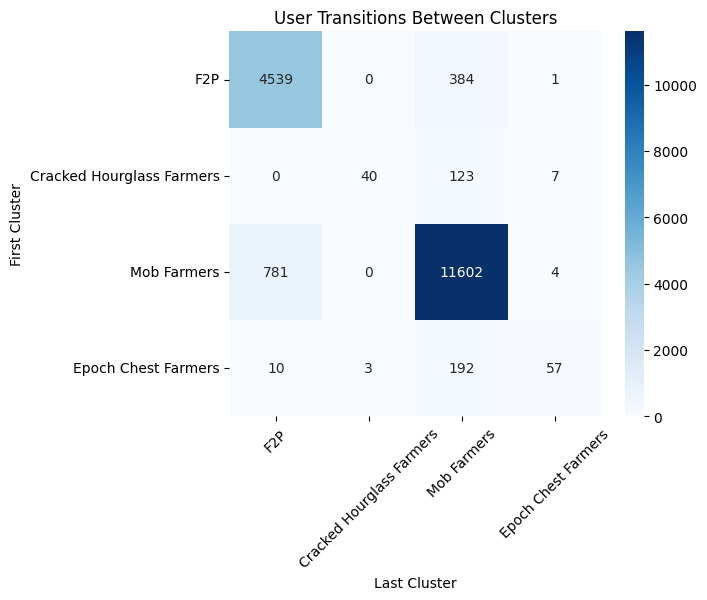

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the transitions into a matrix
transition_matrix = transition_counts.pivot(index='first_cluster', columns='last_cluster', values='count').fillna(0)

# Plot
custom_order = ['F2P', 'Cracked Hourglass Farmers','Mob Farmers', 'Epoch Chest Farmers']

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot as usual
transition_matrix = df.groupby(['first_cluster', 'last_cluster']).size().unstack(fill_value=0)

# Reindex to control axis order
ordered_matrix = transition_matrix.reindex(index=custom_order, columns=custom_order)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(ordered_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("User Transitions Between Clusters")
plt.xlabel("Last Cluster")
plt.xticks(rotation=45)
plt.ylabel("First Cluster")
plt.show()
